### Chatgpt Prompt

Build the following generative models to generate images using the Yelp dataset.
- DDIM

\Evaluate the models using Inception Score and Frechet Inception Distance using a pretrained model
Give 5 generated images 

In [ ]:
import os
import json
import torch
import torch.nn as nn
import torchvision.transforms as T
from torch.utils.data import DataLoader, Dataset
from torchvision.utils import save_image, make_grid
from torchvision.models import inception_v3
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import sqrtm
import pandas as pd

In [24]:
# ----- Configuration -----
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
BATCH_SIZE = 64
IMG_SIZE = 64
# EPOCHS = 50
# TIMESTEPS = 1000
# DDIM_STEPS = 250
# GUIDANCE_SCALE = 7.5

In [3]:
json_path = "/content/drive/MyDrive/Yelp_Balance_Dataset/balanced_photos.json"
data_dir = "/content/drive/MyDrive/Yelp_Balance_Dataset/balanced_photos"

In [4]:
df_balanced_metadata = pd.read_json(json_path, lines=True)

In [5]:
label_to_idx = {}
idx_to_label = {}
samples = []
missing_count = 0
for _, row in df_balanced_metadata.iterrows():
    label = row["label"]
    if label not in label_to_idx:
        idx = len(label_to_idx)
        label_to_idx[label] = idx
        idx_to_label[idx] = label
    # img_path = os.path.join(data_dir, row["photo_id"])
    img_path = os.path.join(data_dir, f"{row['photo_id']}.jpg")
    if os.path.isfile(img_path):
        samples.append((img_path, label_to_idx[label]))
    else:
        missing_count += 1

In [6]:
print("Balanced dataset size:", len(df_balanced_metadata))
print("Images found:", len(samples))
print("Missing files skipped:", missing_count)

Balanced dataset size: 8390
Images found: 8390
Missing files skipped: 0


In [7]:
transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize([0.5], [0.5])
])

In [8]:
# ----- Yelp Dataset and DataLoader (Restored) -----
class YelpDataset(Dataset):
    def __init__(self, samples, transform=None):
        self.transform = transform
        self.samples = []
        for img_path, label in samples:
            try:
                Image.open(img_path).convert("RGB")  # Try opening once to verify
                self.samples.append((img_path, label))
            except:
                continue

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, label

In [9]:
dataset = YelpDataset(samples, transform=transform)
dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

In [58]:
# -----Time Embedding -----
class TimeEmbedding(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.fc = nn.Sequential(
            nn.Linear(1, dim),
            nn.ReLU(),
            nn.Linear(dim, dim)
        )

    def forward(self, t):
        t = t.float().unsqueeze(-1) / 1000
        return self.fc(t)

In [66]:
class FullUNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.time_embed = TimeEmbedding(64)

        self.enc1 = nn.Sequential(
            nn.Conv2d(3, 64, 3, padding=1), nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1), nn.ReLU()
        )
        self.pool1 = nn.MaxPool2d(2)

        self.enc2 = nn.Sequential(
            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(),
            nn.Conv2d(128, 128, 3, padding=1), nn.ReLU()
        )
        self.pool2 = nn.MaxPool2d(2)

        self.middle = nn.Sequential(
            nn.Conv2d(128, 256, 3, padding=1), nn.ReLU(),
            nn.Conv2d(256, 256, 3, padding=1), nn.ReLU()
        )

        self.up2 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.dec2 = nn.Sequential(
            nn.Conv2d(256, 128, 3, padding=1), nn.ReLU(),
            nn.Conv2d(128, 128, 3, padding=1), nn.ReLU()
        )

        self.up1 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.dec1 = nn.Sequential(
            nn.Conv2d(128, 64, 3, padding=1), nn.ReLU(),
            nn.Conv2d(64, 3, 3, padding=1)
        )

    def forward(self, x, t):
        t_embed = self.time_embed(t).view(t.size(0), 64, 1, 1)
        e1 = self.enc1(x)
        e1 = e1 + t_embed
        e2 = self.enc2(self.pool1(e1))
        m = self.middle(self.pool2(e2))
        d2 = self.up2(m)
        d2 = self.dec2(torch.cat([d2, e2], dim=1))
        d1 = self.up1(d2)
        out = self.dec1(torch.cat([d1, e1], dim=1))
        return out

In [67]:
model = FullUNet().to(DEVICE)
optimizer = torch.optim.AdamW(model.parameters(), lr=2e-4, weight_decay=1e-4)

In [68]:
# --- Scheduler ---
def linear_beta_schedule(timesteps):
    return torch.linspace(1e-4, 0.02, timesteps)

timesteps = 1000
betas = linear_beta_schedule(timesteps)
alphas = 1. - betas
alphas_cumprod = torch.cumprod(alphas, dim=0)

In [69]:
# --- q_sample ---
def q_sample(x_start, t, noise=None):
    if noise is None:
        noise = torch.randn_like(x_start)
    alphas_cumprod_device = alphas_cumprod.to(t.device)
    sqrt_alpha_cumprod = torch.sqrt(alphas_cumprod_device[t])[:, None, None, None]
    sqrt_one_minus_alpha_cumprod = torch.sqrt(1 - alphas_cumprod_device[t])[:, None, None, None]
    return sqrt_alpha_cumprod * x_start + sqrt_one_minus_alpha_cumprod * noise

In [70]:
from copy import deepcopy
ema_model = deepcopy(model)
ema_decay = 0.999

In [71]:
def update_ema():
    with torch.no_grad():
        for p, ema_p in zip(model.parameters(), ema_model.parameters()):
            ema_p.data.mul_(ema_decay).add_(p.data, alpha=1 - ema_decay)

In [72]:
NUM_EPOCHS = 50
for epoch in range(NUM_EPOCHS):
    for imgs, _ in dataloader:
        imgs = imgs.to(DEVICE)
        t = torch.randint(0, timesteps, (imgs.size(0),), device=DEVICE).long()
        noise = torch.randn_like(imgs)
        x_t = q_sample(imgs, t, noise)
        pred = model(x_t, t)
        loss = nn.MSELoss()(pred, noise)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        update_ema()

    print(f"Epoch {epoch+1} Loss: {loss.item():.4f}")

Epoch 1 Loss: 0.1082
Epoch 2 Loss: 0.0831
Epoch 3 Loss: 0.0692
Epoch 4 Loss: 0.0825
Epoch 5 Loss: 0.0510
Epoch 6 Loss: 0.0653
Epoch 7 Loss: 0.0426
Epoch 8 Loss: 0.0557
Epoch 9 Loss: 0.0432
Epoch 10 Loss: 0.0497
Epoch 11 Loss: 0.0502
Epoch 12 Loss: 0.0466
Epoch 13 Loss: 0.0625
Epoch 14 Loss: 0.0503
Epoch 15 Loss: 0.0490
Epoch 16 Loss: 0.0556
Epoch 17 Loss: 0.0750
Epoch 18 Loss: 0.0579
Epoch 19 Loss: 0.0685
Epoch 20 Loss: 0.0672
Epoch 21 Loss: 0.0647
Epoch 22 Loss: 0.0509
Epoch 23 Loss: 0.0355
Epoch 24 Loss: 0.0464
Epoch 25 Loss: 0.0768
Epoch 26 Loss: 0.0406
Epoch 27 Loss: 0.0445
Epoch 28 Loss: 0.0374
Epoch 29 Loss: 0.0370
Epoch 30 Loss: 0.0684
Epoch 31 Loss: 0.0573
Epoch 32 Loss: 0.0414
Epoch 33 Loss: 0.0577
Epoch 34 Loss: 0.0339
Epoch 35 Loss: 0.0575
Epoch 36 Loss: 0.0282
Epoch 37 Loss: 0.0247
Epoch 38 Loss: 0.0398
Epoch 39 Loss: 0.0455
Epoch 40 Loss: 0.0368
Epoch 41 Loss: 0.0387
Epoch 42 Loss: 0.0365
Epoch 43 Loss: 0.0539
Epoch 44 Loss: 0.0298
Epoch 45 Loss: 0.0416
Epoch 46 Loss: 0.03

In [73]:
# ----- DDIM Sampler -----
@torch.no_grad()
def ddim_sample(model, shape, ddim_steps=50):
    img = torch.randn(shape).to(DEVICE)
    for i in reversed(range(ddim_steps)):
        t = torch.full((shape[0],), i, dtype=torch.long, device=DEVICE)
        alphas_cumprod_device = alphas_cumprod.to(t.device)
        alpha = alphas_cumprod_device[t].view(-1, 1, 1, 1)
        pred_noise = model(img, t)
        img = (img - (1 - alpha).sqrt() * pred_noise) / alpha.sqrt()
    return img

In [140]:
# ----- Generate 5 Samples Per Label Using EMA Model -----
samples_per_label = []
labels_for_display = []
for label in range(len(label_to_idx)):
    sample = ddim_sample(ema_model, (1, 3, IMG_SIZE, IMG_SIZE))
    samples_per_label.append(sample)
    labels_for_display.append(idx_to_label[label])

In [141]:
samples = torch.cat(samples_per_label, dim=0)
save_image((samples + 1) / 2, "ddim_generated_per_label.png")

In [142]:
# ----- Manual Inception Score & FID -----
from torchvision.models.feature_extraction import create_feature_extractor

inception = inception_v3(pretrained=True, transform_input=False).to(DEVICE)
inception.eval()
feature_extractor = create_feature_extractor(inception, return_nodes={"avgpool": "features"})

/usr/local/lib/python3.11/dist-packages/torchvision/models/feature_extraction.py:175: UserWarning: NOTE: The nodes obtained by tracing the model in eval mode are a subsequence of those obtained in train mode. When choosing nodes for feature extraction, you may need to specify output nodes for train and eval mode separately.
  warnings.warn(msg + suggestion_msg)


In [143]:
# @torch.no_grad()
# def get_inception_features(images):
#     images = torch.nn.functional.interpolate(images, size=(299, 299), mode='bilinear')
#     features = inception.Mixed_7c(images).mean([2, 3])  # Global average pooling on final feature map
#     return features
@torch.no_grad()
def get_inception_features(images):
    images = torch.nn.functional.interpolate(images, size=(299, 299), mode='bilinear')
    normalize = T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    images = normalize(images)
    feats = feature_extractor(images)["features"]
    feats = feats.view(feats.size(0), -1)  # flatten [B, 2048, 1, 1] -> [B, 2048]
    return feats


In [144]:
@torch.no_grad()
def calculate_inception_score(images, splits=5):
    from torchvision.models.inception import inception_v3
    inception_softmax = inception_v3(pretrained=True, transform_input=False).to(DEVICE)
    inception_softmax.eval()
    images = torch.nn.functional.interpolate(images, size=(299, 299), mode='bilinear')
    preds = inception_softmax(images).softmax(dim=1)

    split_scores = []
    split_size = images.shape[0] // splits
    for i in range(splits):
        part = preds[i * split_size: (i + 1) * split_size]
        kl = part * (part.log() - part.mean(dim=0).log())
        kl = kl.sum(dim=1).mean()
        split_scores.append(torch.exp(kl).item())
    return np.mean(split_scores), np.std(split_scores)

In [145]:
@torch.no_grad()
def calculate_fid(real_features, gen_features):
    mu1, sigma1 = real_features.mean(dim=0), torch.cov(real_features.T)
    mu2, sigma2 = gen_features.mean(dim=0), torch.cov(gen_features.T)
    ssdiff = torch.sum((mu1 - mu2) ** 2)
    covmean = torch.from_numpy(sqrtm((sigma1 @ sigma2).cpu().numpy()).real).to(DEVICE)
    return ssdiff + torch.trace(sigma1 + sigma2 - 2 * covmean)


In [146]:
# Compute IS
IS_mean, IS_std = calculate_inception_score(samples)


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=Inception_V3_Weights.IMAGENET1K_V1`. You can also use `weights=Inception_V3_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [147]:
# Compute FID
real_feats = []
for imgs, _ in dataloader:
    imgs = imgs.to(DEVICE)
    resized_imgs = torch.nn.functional.interpolate((imgs + 1) / 2, size=(299, 299), mode='bilinear')
    feats = get_inception_features(resized_imgs)
    real_feats.append(feats)
real_feats = torch.cat(real_feats, dim=0)

In [148]:
gen_feats = get_inception_features(torch.nn.functional.interpolate((samples + 1) / 2, size=(299, 299)))
FID = calculate_fid(real_feats, gen_feats)

In [149]:
# ----- Display Results with Labels -----
print(f"Inception Score: {IS_mean:.2f} ± {IS_std:.2f}")
print(f"FID: {FID:.2f}")

Inception Score: 1.00 ± 0.00
FID: 369.09


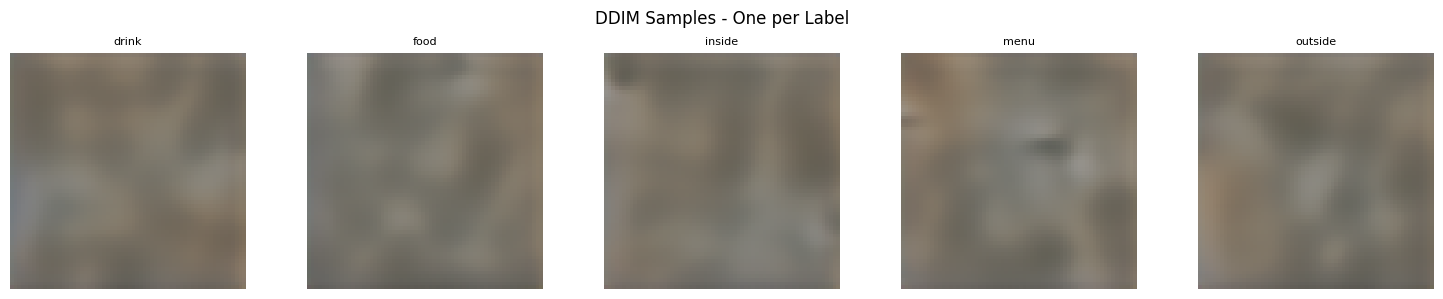

In [150]:
fig, ax = plt.subplots(1, len(samples_per_label), figsize=(15, 3))
for i, img in enumerate(samples_per_label):
    ax[i].imshow((img.squeeze(0).permute(1, 2, 0).cpu() + 1) / 2)
    ax[i].axis('off')
    ax[i].set_title(labels_for_display[i], fontsize=8)
plt.suptitle("DDIM Samples - One per Label")
plt.tight_layout()
plt.show()